In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

In [15]:
df=pd.read_csv("hiring.csv")
df.head()

,experience,test_score(out of 10),interview_score(out of 10),salary($)
0,NaN,8.0,9,50000
1,NaN,8.0,6,45000
2,five,6.0,7,60000
3,two,10.0,10,65000
4,seven,9.0,6,70000


In [16]:
#imputation for experience
df['experience']=df['experience'].fillna('zero')
df

word_to_num = { 'zero': 0, 'one': 1, 'two': 2, 'three': 3, 'four': 4, 'five': 5, 'six': 6, 'seven': 7, 'eight': 8, 'nine': 9, 'ten': 10, 'eleven': 11, 'twelve': 12, 'thirteen': 13, 'fourteen': 14, 'fifteen': 15 }
# Apply mapping
df['experience'] = df['experience'].map(word_to_num)
df

,experience,test_score(out of 10),interview_score(out of 10),salary($)
0,0,8.0,9,50000
1,0,8.0,6,45000
2,5,6.0,7,60000
3,2,10.0,10,65000
4,7,9.0,6,70000
5,3,7.0,10,62000
6,10,NaN,7,72000
7,11,7.0,8,80000


In [17]:
#imputation for test_score
df['test_score(out of 10)']=df['test_score(out of 10)'].fillna(df['test_score(out of 10)'].median())
df
#(median(df['test_score(out of 10)']))

,experience,test_score(out of 10),interview_score(out of 10),salary($)
0,0,8.0,9,50000
1,0,8.0,6,45000
2,5,6.0,7,60000
3,2,10.0,10,65000
4,7,9.0,6,70000
5,3,7.0,10,62000
6,10,8.0,7,72000
7,11,7.0,8,80000


In [18]:
X=df.drop('salary($)',axis=1)
X

,experience,test_score(out of 10),interview_score(out of 10)
0,0,8.0,9
1,0,8.0,6
2,5,6.0,7
3,2,10.0,10
4,7,9.0,6
5,3,7.0,10
6,10,8.0,7
7,11,7.0,8


In [19]:
y=df['salary($)']
y

0    50000
1    45000
2    60000
3    65000
4    70000
5    62000
6    72000
7    80000
Name: salary($), dtype: int64

In [20]:
reg=LinearRegression()
reg.fit(X,y)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [27]:
reg.predict(pd.DataFrame([[2, 9, 6]],columns=X.columns))

array([53205.96797671])

In [28]:
reg.predict(pd.DataFrame([[12, 10, 10]],columns=X.columns))

array([92002.18340611])

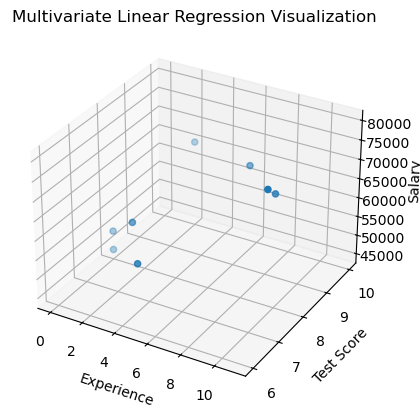

In [29]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

ax.scatter(df['experience'],
           df['test_score(out of 10)'],
           df['salary($)'])

ax.set_xlabel("Experience")
ax.set_ylabel("Test Score")
ax.set_zlabel("Salary")

plt.title("Multivariate Linear Regression Visualization")
plt.show()

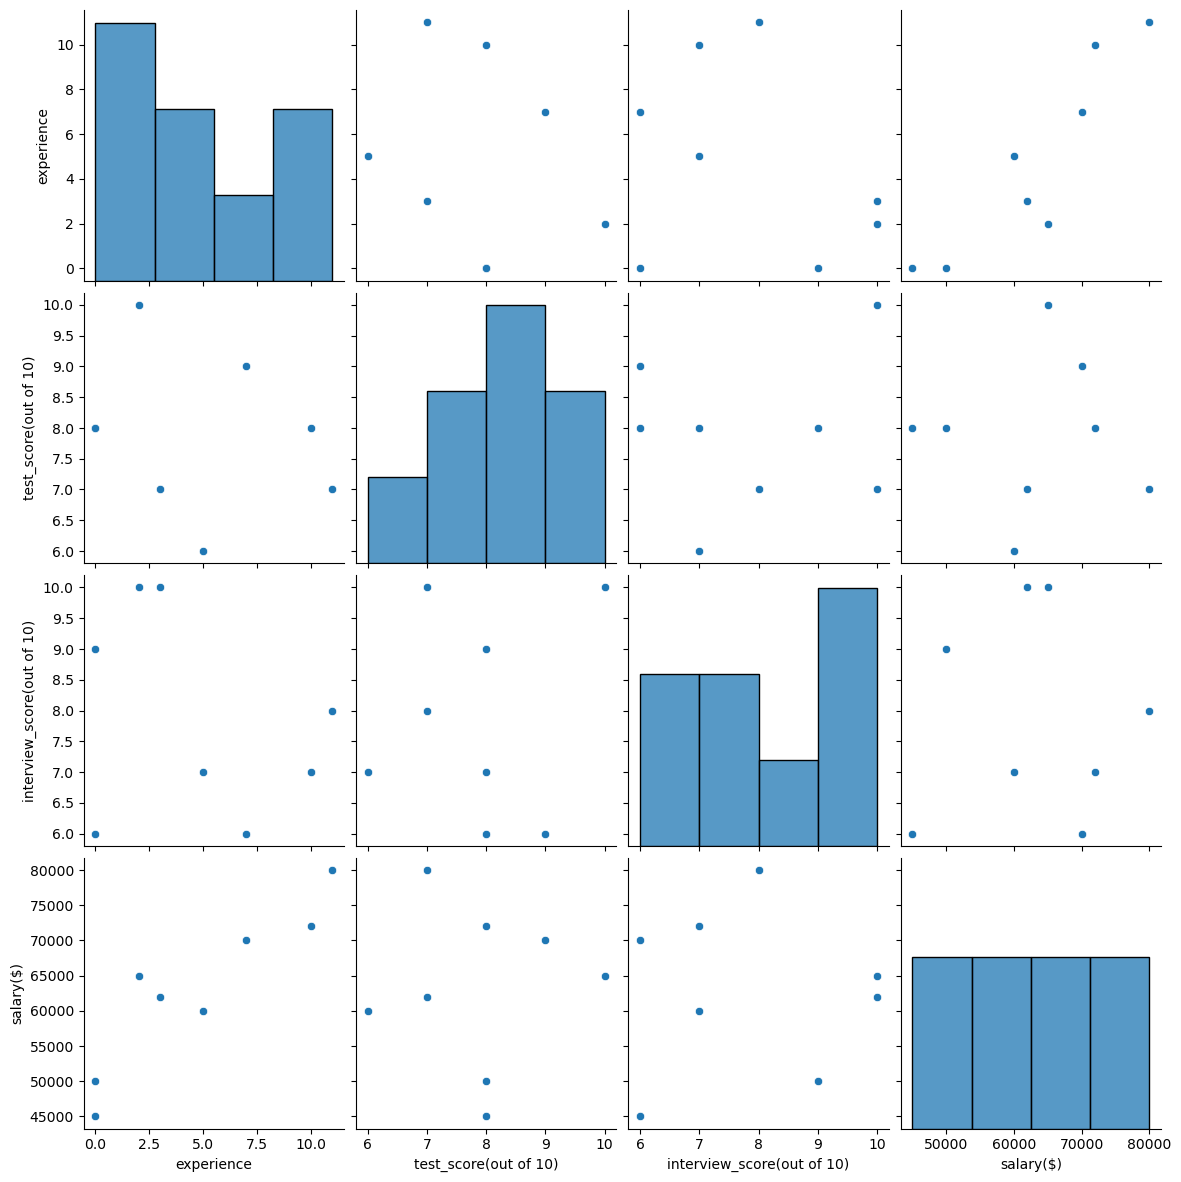

In [30]:
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
sns.pairplot(df, height=3)
plt.show()

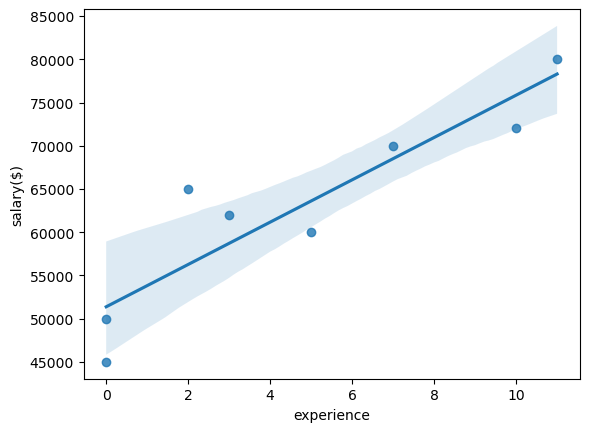

In [31]:
sns.regplot(x="experience", y="salary($)", data=df)
plt.show()